# Capítulo 3: IA para la Detección de Amenazas *(Versión Simulada)*

## 3.1. Introducción

Esta versión utiliza un **dataset sintético** generado automáticamente. Implementa:
- **Isolation Forest** para detección de anomalías no supervisada.
- **Autoencoder con MLP** (sklearn) para detección de intrusiones sin necesidad de TensorFlow.

---
## 3.2. Generación de datos simulados

In [1]:
import numpy as np
import pandas as pd
import os

np.random.seed(42)
os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)

n_normal, n_anomaly = 5000, 250

normal = pd.DataFrame({
    'bytes_sent':  np.random.exponential(500, n_normal).astype(int),
    'bytes_recv':  np.random.exponential(800, n_normal).astype(int),
    'duration':    np.random.exponential(30, n_normal).round(2),
    'protocol':    np.random.choice(['TCP', 'UDP', 'ICMP'], n_normal, p=[0.7, 0.25, 0.05]),
    'src_port':    np.random.randint(1024, 65535, n_normal),
    'dst_port':    np.random.choice([80, 443, 53, 22, 8080], n_normal),
    'label':       0
})
anomaly = pd.DataFrame({
    'bytes_sent':  np.random.exponential(5000, n_anomaly).astype(int),
    'bytes_recv':  np.random.exponential(50, n_anomaly).astype(int),
    'duration':    np.random.exponential(200, n_anomaly).round(2),
    'protocol':    np.random.choice(['TCP', 'UDP', 'ICMP'], n_anomaly, p=[0.3, 0.3, 0.4]),
    'src_port':    np.random.randint(1, 1024, n_anomaly),
    'dst_port':    np.random.choice([4444, 31337, 6667, 9999], n_anomaly),
    'label':       1
})

data_sim = pd.concat([normal, anomaly]).sample(frac=1, random_state=42).reset_index(drop=True)
data_sim.to_csv('data/network_traffic.csv', index=False)
print(f"[OK] data/network_traffic.csv: {len(data_sim)} registros")

[OK] data/network_traffic.csv: 5250 registros


---
## 3.3. Exploración y preprocesamiento

<class 'pandas.DataFrame'>
RangeIndex: 5250 entries, 0 to 5249
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   bytes_sent  5250 non-null   int64  
 1   bytes_recv  5250 non-null   int64  
 2   duration    5250 non-null   float64
 3   protocol    5250 non-null   str    
 4   src_port    5250 non-null   int64  
 5   dst_port    5250 non-null   int64  
 6   label       5250 non-null   int64  
dtypes: float64(1), int64(5), str(1)
memory usage: 287.2 KB
None
         bytes_sent   bytes_recv     duration      src_port      dst_port  \
count   5250.000000  5250.000000  5250.000000   5250.000000   5250.000000   
mean     708.590286   737.408381    38.099036  31498.768190   2409.126286   
std     1507.413468   766.255814    60.837992  19563.672568   4784.489712   
min        0.000000     0.000000     0.000000      3.000000     22.000000   
25%      147.250000   188.250000     8.912500  14563.250000     53.000000   
50%      

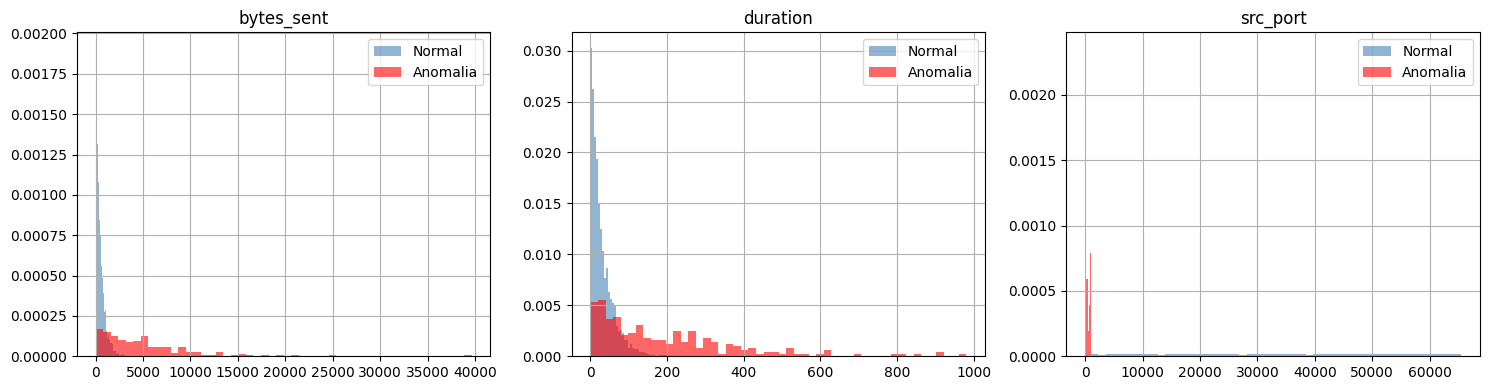

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

data = pd.read_csv('data/network_traffic.csv')
print(data.info())
print(data.describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['bytes_sent', 'duration', 'src_port']):
    data[data['label']==0][col].hist(bins=50, alpha=0.6, ax=axes[i], color='steelblue', label='Normal', density=True)
    data[data['label']==1][col].hist(bins=50, alpha=0.6, ax=axes[i], color='red', label='Anomalia', density=True)
    axes[i].set_title(col); axes[i].legend()
plt.tight_layout()
plt.savefig('data/exploracion_trafico.png', dpi=150)
plt.show()

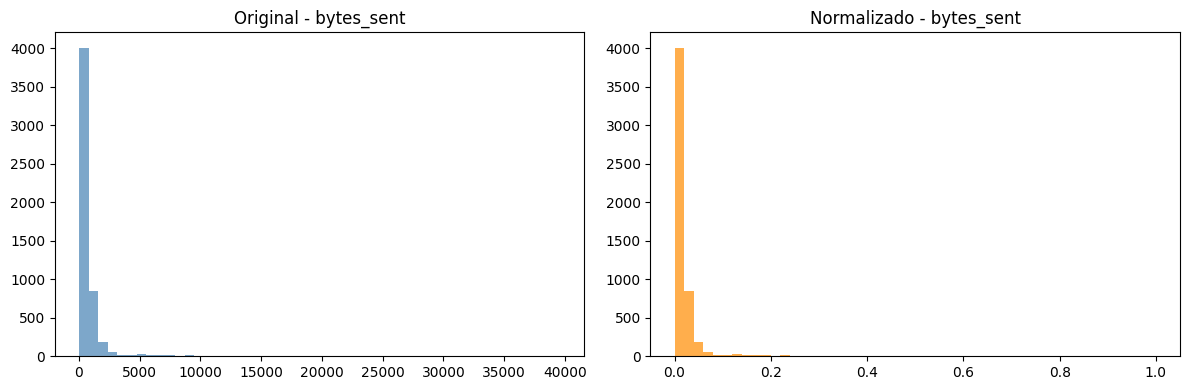

In [3]:
data = pd.read_csv('data/network_traffic.csv').dropna()
le = LabelEncoder()
if data['protocol'].dtype == object:
    data['protocol'] = le.fit_transform(data['protocol'])

feature_cols = ['bytes_sent', 'bytes_recv', 'duration', 'src_port']
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[feature_cols])
scaled_df = pd.DataFrame(scaled_data, columns=feature_cols)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(data['bytes_sent'], bins=50, color='steelblue', alpha=0.7); axes[0].set_title('Original - bytes_sent')
axes[1].hist(scaled_df['bytes_sent'], bins=50, color='darkorange', alpha=0.7); axes[1].set_title('Normalizado - bytes_sent')
plt.tight_layout()
plt.savefig('data/network_distribution.png', dpi=150)
plt.show()

---
## 3.4. Isolation Forest

Anomalias detectadas: 263 / 5250
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      5000
    Anomalia       0.59      0.62      0.60       250

    accuracy                           0.96      5250
   macro avg       0.79      0.80      0.79      5250
weighted avg       0.96      0.96      0.96      5250



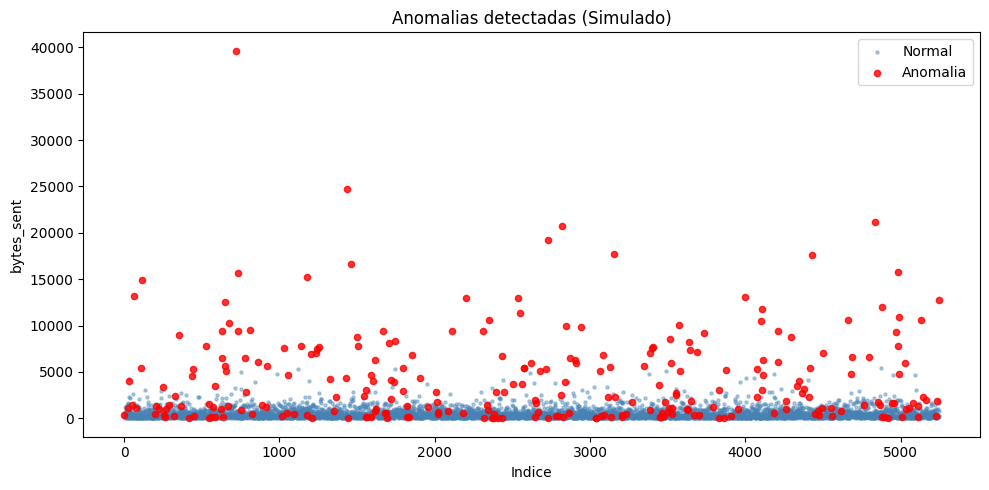

[OK] models/isolation_forest.pkl guardado


In [4]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report
import joblib

model = IsolationForest(n_estimators=200, contamination=0.05, random_state=42, n_jobs=-1)
model.fit(scaled_data)

predictions = model.predict(scaled_data)
scores = model.decision_function(scaled_data)
data['anomaly'] = predictions
data['anomaly_score'] = scores

anomalous = data[data['anomaly'] == -1]
print(f"Anomalias detectadas: {len(anomalous)} / {len(data)}")

y_pred = (predictions == -1).astype(int)
print(classification_report(data['label'], y_pred, target_names=['Normal', 'Anomalia']))

plt.figure(figsize=(10, 5))
normal_pts = data[data['anomaly'] == 1]
plt.scatter(normal_pts.index, normal_pts['bytes_sent'], s=5, c='steelblue', alpha=0.4, label='Normal')
plt.scatter(anomalous.index, anomalous['bytes_sent'], s=20, c='red', alpha=0.8, label='Anomalia')
plt.xlabel('Indice'); plt.ylabel('bytes_sent')
plt.title('Anomalias detectadas (Simulado)')
plt.legend(); plt.tight_layout()
plt.savefig('data/anomaly_detection.png', dpi=150)
plt.show()

joblib.dump(model, 'models/isolation_forest.pkl')
joblib.dump(scaler, 'models/scaler_network.pkl')
print("[OK] models/isolation_forest.pkl guardado")

---
## 3.5. Autoencoder con MLPRegressor (sklearn)

Usamos `MLPRegressor` de scikit-learn como autoencoder funcional: entrenamos sobre datos normales para reconstruirlos, y medimos el **error de reconstrucción** en datos de prueba. Los datos con alto error son anomalías.

Umbral de deteccion (p95): 0.001066
Anomalias detectadas: 476

=== Reporte (Autoencoder MLP) ===
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97      5000
    Anomalia       0.49      0.94      0.65       250

    accuracy                           0.95      5250
   macro avg       0.75      0.95      0.81      5250
weighted avg       0.97      0.95      0.96      5250



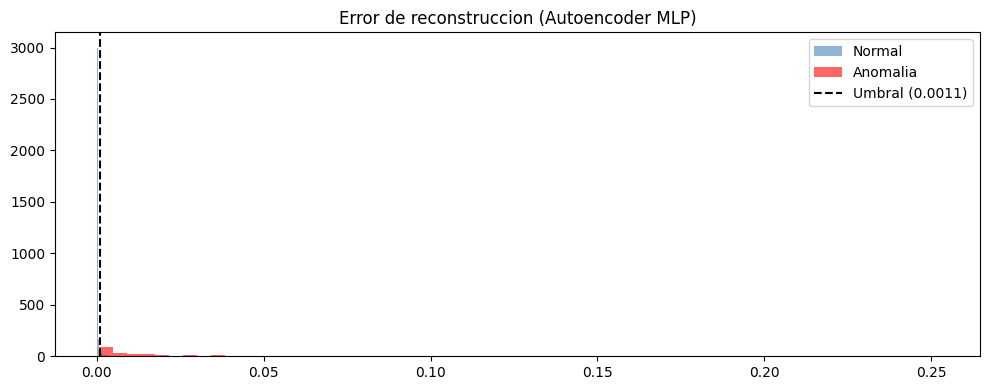

[OK] models/autoencoder_ids.pkl guardado


In [5]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split

labels = data['label'].values
X_normal = scaled_data[labels == 0]
X_train, X_val = train_test_split(X_normal, test_size=0.2, random_state=42)

# MLPRegressor como autoencoder: entrada y salida son los mismos datos
autoencoder = MLPRegressor(
    hidden_layer_sizes=(16, 8, 16),   # encoder: 16->8, decoder: 8->16
    activation='relu',
    max_iter=200,
    random_state=42,
    verbose=False
)
autoencoder.fit(X_train, X_train)

# Error de reconstruccion
X_reconstructed = autoencoder.predict(scaled_data)
mse_err = np.mean((scaled_data - X_reconstructed) ** 2, axis=1)

train_reconstructed = autoencoder.predict(X_train)
train_mse = np.mean((X_train - train_reconstructed) ** 2, axis=1)
threshold = np.percentile(train_mse, 95)
print(f"Umbral de deteccion (p95): {threshold:.6f}")

anomalies_detected = (mse_err > threshold).astype(int)
print(f"Anomalias detectadas: {anomalies_detected.sum()}")

print("\n=== Reporte (Autoencoder MLP) ===")
print(classification_report(labels, anomalies_detected, target_names=['Normal', 'Anomalia']))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(mse_err[labels == 0], bins=60, alpha=0.6, color='steelblue', label='Normal', density=True)
ax.hist(mse_err[labels == 1], bins=60, alpha=0.6, color='red', label='Anomalia', density=True)
ax.axvline(threshold, color='black', linestyle='--', label=f'Umbral ({threshold:.4f})')
ax.set_title('Error de reconstruccion (Autoencoder MLP)')
ax.legend()
plt.tight_layout()
plt.savefig('data/autoencoder_loss.png', dpi=150)
plt.show()

joblib.dump(autoencoder, 'models/autoencoder_ids.pkl')
data['anomaly_ae'] = anomalies_detected
data.to_csv('data/network_traffic_predictions.csv', index=False)
print("[OK] models/autoencoder_ids.pkl guardado")